# Slow-Light Black Hole Imaging from GRMHD Simulations

In this notebook, we move beyond the fast-light approximation and explore slow-light radiative transfer. 
This approach accounts for the time-dependent evolution of the plasma, enabling more physically consistent 
black hole images derived from GRMHD simulations.

- In Jipole, this is done by enabling the variable SLOW_LIGHT = true

In [10]:
# CONFIGURACIÓN GLOBAL DEL MODELO
# Igual que en el notebook de fast-light, se definen las variables globales
# ANTES de hacer include, porque include no crea un scope nuevo en Julia:
# el contenido de main.jl hereda estas constantes directamente.
#
# La diferencia clave respecto al notebook anterior es SLOW_LIGHT = true,
# lo que activa la carga del módulo slowlight.jl dentro de main.jl:
#   if(SLOW_LIGHT)
#       include("./slowlight.jl")
#   end

const MODEL = "iharm"    # Modelo GRMHD: lee datos reales de archivos .h5
const MBH = 6.2e9        # Masa del agujero negro en masas solares (M87*)
const SLOW_LIGHT = true  # Activa el modo slow light: cada fotón usa el tiempo correcto de emisión
include("../src/main.jl");  # Carga Jipole completo. El ; suprime la salida en Jupyter


Using model: iharm, change src/set_globals.jl to modify.
Adding slowlight.jl file...


We must account for the time evolution of the plasma during photon propagation. In practice, this means that a single simulation snapshot is no longer sufficient.

Instead, slow-light radiative transfer requires access to multiple GRMHD dump files, each corresponding to a different simulation time. As photons travel through the domain, their trajectories intersect the simulation at different times, and the local fluid quantities (e.g., density, temperature, magnetic field) must be interpolated from the appropriate dumps.

In this notebook, we therefore work with a sequence of simulation outputs stored as:


In [11]:
# RUTA AL ARCHIVO DE SIMULACIÓN GRMHD
# A diferencia del notebook de fast-light que usaba un solo dump,
# slow light requiere múltiples snapshots temporales.
#
# Aquí se define la ruta al PRIMER dump de la secuencia. Los dumps siguientes
# se cargan automáticamente usando update_dump_path(), que avanza al siguiente
# archivo en la secuencia cada vez que se le llama.
#
# El nombre del archivo contiene información del modelo:
#   SANE   → estado magnético del disco (Standard And Normal Evolution)
#   a+0.94 → spin del agujero negro (a = 0.94, rotación prógrada)
#   MKS    → coordenadas Modified Kerr-Schild
#   0900   → índice del dump (snapshot número 900 de la simulación)

const all_dumps_path = "/home/pedro/kharma/iharm3d_out/tmp.%05d.h5"


"/home/pedro/kharma/iharm3d_out/tmp.%05d.h5"

To perform slow-light, we must specify both the temporal range of the simulation data and how frequently images are produced. 

The parameter `dump_max` sets the extent of the available simulation snapshots, meaning that the radiative transfer will interpolate fluid quantities using dumps from the initial index up to this maximum value. 

In this example, the evolution of the plasma is sampled from dump 0 through dump 10, providing a finite time window over which photon trajectories are evaluated.

The parameter `ImageCadence` controls how often images are generated in physical time. For instance, a value of 10 corresponds to producing one image every \(10\ r_g / c\), where \(r_g\) is the gravitational radius. This defines the temporal resolution of the resulting sequence of images and ultimately determines how smoothly the time variability of the system is captured.


All of this information is stored in an `OfSlowLight` structure, which manages how simulation data is loaded and interpolated in time during the ray-tracing process.

At any given moment, only a small subset of the available dumps is kept in memory to remain efficient. In this implementation, we always keep three dump files loaded. These define a sliding time window over which interpolation is performed. The variables `tA` and `tB` correspond to the times of two consecutive dumps (for example, dump 0 and dump 1). If a photon intersects the simulation at a time between `tA` and `tB`, the fluid quantities are obtained by interpolating between these two snapshots. As the photon propagates forward in time and moves beyond `tB`, the window shifts, and interpolation is then performed between the next pair of dumps (e.g., dumps 1 and 2, then 2 and 3, and so on).

The field `current_dumps_path` keeps track of the next dump file to be loaded into memory as this sliding window advances. This allows the code to progressively stream simulation data without loading all dumps at once.

`tf` represents the final time of the simulation data, corresponding to the last available dump as defined by `dump_max`. This sets the upper temporal boundary for the slow-light calculation.

In [12]:
# CONFIGURACIÓN DE LA VENTANA TEMPORAL DE SLOW LIGHT
#
# dump_max: índice del último dump disponible. Define el límite temporal
# superior de la simulación. En este caso se tienen dumps del 0 al 10.
#
# ImageCadence: cada cuántas unidades de tiempo (rg/c) se genera una imagen.
# Un valor de 10 significa una imagen cada 10 M (donde M = rg/c en unidades geométricas).
#
# OfSlowLight: struct definido en slowlight.jl que agrupa toda la información
# necesaria para manejar la ventana deslizante de interpolación temporal:
#   - dump_max: índice máximo de dumps disponibles
#   - 0: índice del dump actual (empieza en 0)
#   - ImageCadence: cadencia de imágenes
#   - 0.0, 0.0, 0.0: tA, tB, tf inicializados en 0 (se llenan después)
#   - "": ruta al dump actual (se llena con update_dump_path())
#
# update_dump_path(): función de slowlight.jl que determina la ruta
# del siguiente dump a cargar y avanza el contador interno.

const dump_max = 10
const ImageCadence = 10 
params_slowlight = OfSlowLight(dump_max, 0, ImageCadence, 0.0, 0.0, 0.0, "")
params_slowlight.current_dumps_path = update_dump_path()


"/home/pedro/kharma/iharm3d_out/tmp.00000.h5"

In [13]:
# PARÁMETROS DEL MODELO DE TEMPERATURA (PRESCRIPCIÓN R-β)
# Estos parámetros controlan cómo se distribuye la temperatura entre
# iones y electrones del plasma, siguiendo Mościbrodzka et al. (2016).
#
# trat_large = 20.0
#   Razón Ti/Te en regiones de BAJA magnetización (disco de acreción).
#   Los iones están 20 veces más calientes que los electrones en el disco.
#
# trat_small = 1.0
#   Razón Ti/Te en regiones de ALTA magnetización (jet).
#   Iones y electrones tienen temperatura similar en el jet.
#
# beta_crit = 1.0
#   Valor de plasma-β que separa el régimen de disco (β > β_crit)
#   del régimen de jet (β < β_crit). β = presión gas / presión magnética.
#
# th_beg = 1.74e-2
#   Ángulo polar mínimo (en radianes) para considerar emisión.
#   Evita singularidades numéricas cerca del eje de rotación.
#
# sigma_cut = 1.0
#   Corte en magnetización σ. Celdas con σ > sigma_cut se consideran
#   parte del jet y se excluyen de la emisión (plasma demasiado magnetizado).
#
# sigma_cut_high = -1.0
#   Corte superior de σ. El valor -1.0 desactiva este corte.

trat_large = 20. 
const trat_small = 1. 
const beta_crit = 1.0 
const th_beg = 1.74e-2 
const sigma_cut = 1.0 
const sigma_cut_high = -1.0;


In [14]:
# LECTURA DEL HEADER DEL DUMP
# Lee los metadatos del primer dump: tamaño del grid, spin del agujero negro,
# coordenadas, unidades físicas, etc.
#
# Se usa current_dumps_path del struct params_slowlight, que apunta al primer
# dump de la secuencia definido por update_dump_path() en la celda anterior.
#
# El resultado params contiene, entre otras cosas:
#   params.a    → spin del agujero negro
#   params.Rout → radio exterior del dominio de simulación

const params = read_header(params_slowlight.current_dumps_path);


Initializing grid from: /home/pedro/kharma/iharm3d_out/tmp.00000.h5


custom electron model loaded from dump file...
Using mixed tp_over_te with trat_small = 1, trat_large = 20, and beta_crit = 1
Using Funky Modified Kerr-Schild coordinates FMKS
MKS parameters a: 0.937500 hslope: 0.300000 Rin: 1.001876 Rout: 1000.000000
FMKS parameters poly_xt: 0.820000 poly_alpha: 14.000000 mks_smooth: 0.500000 poly_norm: 0.757817
Grid start (startx): 1.874000951149755e-03, 0.000000000000000e+00, 0.000000000000000e+00 stop (stopx): 6.907755278982137e+00, 1.000000000000000e+00, 6.283185307179586e+00
grid dx: 5.395219748461709e-02, 7.812500000000000e-03, 6.283185307179586e+00


We begin by initializing a vector of simulation data containing three dump files and loading the first three snapshots into memory. These initial dumps define the starting interpolation window for the slow-light calculation.

As photon trajectories advance in time, this window must be updated to ensure that the appropriate simulation data is always available. All loading of new dump files and shifting of the sliding window is handled internally by the `update_data!` function (defined in `slowlight.jl`). This routine takes care of discarding old snapshots, loading new ones, and maintaining the correct ordering for time interpolation throughout the radiative transfer.

In [15]:
# CARGA INICIAL DE LOS TRES DUMPS (VENTANA DESLIZANTE)
#
# A diferencia del notebook de fast-light donde simulation_data tenía 1 elemento,
# aquí se reservan 3 posiciones. Esto es la ventana deslizante de slow light:
#   simulation_data[1] → dump más antiguo (tA)
#   simulation_data[2] → dump intermedio (tB)
#   simulation_data[3] → dump más reciente (reserva para el siguiente paso)
#
# Cada llamada a load_data avanza automáticamente el puntero interno de
# current_dumps_path al siguiente archivo de la secuencia. Por eso tres
# llamadas consecutivas cargan tres dumps distintos sin especificar rutas.
#
# tA y tB: tiempos de coordenada de los dumps 1 y 2 respectivamente.
# Definen el intervalo de interpolación inicial. Si un fotón fue emitido
# en un tiempo entre tA y tB, Jipole interpola linealmente entre ambos dumps.
#
# tf: tiempo del último dump disponible (dump_max). Define el límite temporal
# superior de la simulación, más allá del cual no hay datos.
# get_specific_dump_time lee el tiempo de coordenada de ese dump sin cargarlo completo.

const simulation_data = Vector{IharmData}(undef, 3)

# everytime you load a file slow_light mode will automatically advance to the next one
simulation_data[1] = load_data(params_slowlight.current_dumps_path, trat_large)
simulation_data[2] = load_data(params_slowlight.current_dumps_path, trat_large)
simulation_data[3] = load_data(params_slowlight.current_dumps_path, trat_large)

params_slowlight.tA = simulation_data[1].t;  # Tiempo del dump más antiguo en memoria
params_slowlight.tB = simulation_data[2].t;  # Tiempo del dump siguiente

params_slowlight.tf = get_specific_dump_time(params_slowlight.dump_max);  # Límite temporal superior


Loading data from '/home/pedro/kharma/iharm3d_out/tmp.00000.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)
Loading data from '/home/pedro/kharma/iharm3d_out/tmp.00001.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)
Loading data from '/home/pedro/kharma/iharm3d_out/tmp.00002.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)


In [7]:
# PARÁMETROS DEL OBSERVADOR Y LA CÁMARA
# Idénticos en concepto al notebook de fast-light. Se definen la posición
# del observador y las propiedades de la imagen.
#
# NOTA: th = 163.0° aquí (vs 60° en el notebook anterior).
# 163° es casi de espaldas al eje de rotación, equivalente a ver el sistema
# con una inclinación de 180° - 163° = 17° respecto al plano ecuatorial.
# Esto corresponde a una vista casi de frente al jet, similar a M87*.

# Observer distance in gravitational radii (Rg)
const ro = 1000.0

# Inclination angle (deg) — angle between the observer and the BH spin axis
const th = 163.0

# Azimuthal angle (deg) — rotation around the system
const phi = 0.0

# Image resolution — total geodesics traced = res^2
const res = 128
const pixels_x = 128
const pixels_y = 128

# Distance to the source (in parsecs, converted to code units)
const SourceD = 16.9e6 * PC

# Event horizon radius for a Kerr black hole
const Rh = 1 + sqrt(1. - params.a * params.a)

# Observing frequency (Hz), e.g. 230 GHz for EHT-like images
const freq = 230e9

# Image plane size (in Rg), scaled from physical distance
const DXsize = SourceD / L_unit / MUAS_PER_RAD * 160
const DYsize = SourceD / L_unit / MUAS_PER_RAD * 160

# Field of view (radians)
const fovx = DXsize / ro
const fovy = DYsize / ro

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0


0.0

## Geodesic Ray-Tracing and Time Boundary Estimation

In this stage, we perform the core ray-tracing calculation to construct the final image from the GRMHD simulation. The camera position is first defined in the native coordinate system of the spacetime, and the observed frequency is converted into a dimensionless unit system appropriate for the geodesic integration.

We allocate memory for the auxiliary arrays to track the number of integration steps per pixel and the number of midplane crossings. Because the computation is parallelized across multiple threads, each thread is assigned its own scratch space to store geodesic trajectories. Each trajectory is represented as a sequence of spacetime points and wavevectors, with a fixed maximum number of integration steps to ensure memory safety.

Following the conventions used in ipole, we compute two diagnostic time boundaries: one corresponding to the first entrance into the emission region and another corresponding to the last relevant interaction before the photon escapes. These quantities are tracked per thread and later reduced across all threads to obtain global extrema. In addition, we record the absolute minimum photon time encountered across all rays, which defines the earliest emission time needed for the simulation.

After all pixels have been processed, the intensity map is scaled by the appropriate frequency factor, completing the radiative transfer step.

Finally, temporary arrays storing thread-local geodesics and timing information are discarded, and garbage collection is triggered to free memory before proceeding to the next stage of the calculation. This ensures that only the necessary global quantities are retained for subsequent slow-light processing.

In [8]:
# RAY TRACING CON ALMACENAMIENTO PERMANENTE DE GEODÉSICAS
#
# Esta celda es la más importante del notebook y tiene dos diferencias
# fundamentales respecto al notebook de fast-light:
#
# 1. all_geodesics: en fast-light los buffers por hilo se sobreescribían
#    con cada píxel. Aquí se GUARDAN TODAS las geodésicas permanentemente
#    en all_geodesics[i,j]. Esto es necesario porque slow light reutiliza
#    cada geodésica múltiples veces (una por cada imagen del movie).
#
# 2. Cálculo de tiempos diagnóstico (t0, tgeof, tgeoi):
#    Slow light necesita saber qué rango temporal de dumps cargar.
#    Se calculan tres valores siguiendo la convención de ipole:
#
#    t0     → tiempo más negativo absoluto entre todos los fotones.
#             Define el dump más antiguo que se necesita.
#
#    tgeof  → tiempo más negativo dentro de la zona de emisión activa
#             (r < 100 Rg, con Kcon_r < 0, es decir, el fotón está
#             acercándose al agujero negro). Es el tiempo del dump
#             más antiguo necesario en la zona de emisión.
#
#    tgeoi  → tiempo menos negativo dentro de la zona de emisión activa.
#             Es el dump más reciente necesario en la zona de emisión.
#
# Al final se liberan los buffers temporales y se llama al garbage collector
# (GC.gc()) para liberar RAM antes de procesar las imágenes.

# Calculate the camera position in native coordinates
Xcamera = MVec4(camera_position(ro, th, phi, params.a, params.Rout))

# Unitless frequency 
const freq_unitless = freq * HPL / (ME * CL * CL)

# Array que almacena el número de cruces por el plano ecuatorial por píxel
# y el número de pasos de integración usados por píxel
midplane_crossings = zeros(Int, pixels_x, pixels_y)
nsteps = zeros(Int, pixels_x, pixels_y)

# Number of threads used in the calculation
const nthreads = Threads.nthreads() + 1

println("Allocating workspaces for  threads...")
# Number of maximum steps in the geodesic calculation
const maxnstep = 15000

# Buffers temporales por hilo: igual que en fast-light, cada hilo tiene
# su propio espacio de trabajo para evitar condiciones de carrera.
# La diferencia es que aquí el contenido se copiará a all_geodesics.
dummy_svec = @SVector zeros(4)
dummy_traj = OfTrajS(0.0, dummy_svec, dummy_svec, dummy_svec, dummy_svec)

thread_trajs = [Vector{OfTrajS}(undef, maxnstep) for _ in 1:nthreads]
for t in 1:nthreads
    for k in 1:maxnstep
        thread_trajs[t][k] = dummy_traj
    end
end

# Almacenamiento permanente de todas las geodésicas.
# Matrix de tamaño pixels_x x pixels_y donde cada entrada es un Vector
# de OfTrajS con exactamente nstep elementos (los pasos reales de esa geodésica).
const all_geodesics = Matrix{Vector{OfTrajS}}(undef, pixels_x, pixels_y) ##Geodesicas

# Arrays de diagnóstico temporal, uno por hilo para evitar condiciones de carrera.
# Inicializado en 0.0 porque los tiempos de los fotones son negativos.
thread_t0 = zeros(Float64, nthreads)

# tgeoi necesita encontrar el máximo (menos negativo), se inicializa muy negativo
thread_tgeoi = fill(-1e100, nthreads) 

# tgeof necesita encontrar el mínimo (más negativo), se inicializa en cero
thread_tgeof = zeros(Float64, nthreads)

p = Progress(
    pixels_x * pixels_y; 
    desc = "Raytracing Image...", 
    showspeed = true, 
    barlen = 30
)
ProgressMeter.ijulia_behavior(:clear)

println("Tracing Geodesics...")
Threads.@threads for i in 0:(pixels_x - 1)
    tid = Threads.threadid()  # ID del hilo actual
    
    for j in 0:(pixels_y - 1)
        # Traza la geodésica para el píxel (i,j) y almacena el resultado
        # en el buffer del hilo. nstep = pasos reales usados.
        # midplane_crossings cuenta cuántas veces el fotón cruzó el plano ecuatorial
        # (relevante para identificar imágenes de orden superior n=1,2,...)
        nstep, midplane_crossings[i+1,j+1] = get_pixel(
            thread_trajs[tid], i, j, Xcamera, 
            fovx, fovy, freq_unitless, 
            pixels_x, pixels_y, params.a, 
            Rh, params.Rout, params.rmax_geo, xoff, yoff
        ) 
        nsteps[i+1, j+1] = nstep  # Guarda el número de pasos para este píxel
        
        # Copia los primeros nstep elementos del buffer temporal al almacenamiento permanente.
        # 1:nstep descarta los pasos no usados (el buffer tiene maxnstep=15000 posiciones).
        all_geodesics[i + 1, j + 1] = thread_trajs[tid][1:nstep]

        # Tiempo de coordenada del último paso de la geodésica (el más negativo = más antiguo)
        final_step_time = thread_trajs[tid][nstep].X[1]
        if final_step_time < thread_t0[tid]
            thread_t0[tid] = final_step_time  # Actualiza el mínimo absoluto del hilo
        end

        # Calculo de tgeoi y tgeof siguiendo la convención de ipole:
        # Se recorre cada paso de la geodésica buscando cuándo el fotón
        # está dentro de la zona de emisión activa (r < 100 Rg)
        pixel_tgeoi = 1.0  # Inicializado positivo para detectar el primer cruce
        pixel_tgeof = 1.0
        for k in 1:nstep
            X = thread_trajs[tid][k].X
            K = thread_trajs[tid][k].Kcon
        
            log_r = X[2]       # En coordenadas MKS, X[2] = log(r)
            t_coord = X[1]     # Tiempo de coordenada del paso k
            k_r = K[2]         # Componente radial del 4-momento
        
            # tgeoi: primer momento en que el fotón entra a r < 100 Rg
            if pixel_tgeoi > 0.0 && log_r < log(100.0)
                pixel_tgeoi = t_coord
            end
        
            # tgeof: momento en que el fotón sale de r < 100 Rg moviéndose hacia afuera (k_r < 0)
            if pixel_tgeof > 0.0 && log_r > log(100.0) && k_r < 0.0
                pixel_tgeof = t_coord
            end
        end
        final_step_time = thread_trajs[tid][nstep].X[1]
        
        # Reduce los valores del píxel al acumulador del hilo
        if pixel_tgeoi < 0.0 && pixel_tgeoi > thread_tgeoi[tid]
            thread_tgeoi[tid] = pixel_tgeoi  # Guarda el menos negativo (más reciente)
        end
        if pixel_tgeof < 0.0 && pixel_tgeof < thread_tgeof[tid]
            thread_tgeof[tid] = pixel_tgeof  # Guarda el más negativo (más antiguo)
        elseif pixel_tgeof > 0.0 && final_step_time < thread_tgeof[tid]
            thread_tgeof[tid] = final_step_time
        end
        
        ProgressMeter.next!(
                p; 
                showvalues = [
                    (:thread_id, tid), 
                    (:pixel, "(, )"), 
                    (:total_done, "/")
            ]
        )
    end
end

finish!(p);

# Reducción final: combina los resultados de todos los hilos en valores globales.
# minimum() y maximum() recorren el array de nthreads valores y devuelven el extremo.
t0 = minimum(thread_t0)
tgeof = minimum(thread_tgeof)  # El tiempo más negativo → dump más antiguo necesario
tgeoi = maximum(thread_tgeoi)  # El tiempo menos negativo → dump más reciente necesario

println("Calculated t0 (absolute longest time): ")
println("Calculated tgeof (oldest active time): ")
println("Calculated tgeoi (newest active time): ")

# Liberación de memoria: se eliminan los arrays temporales asignándoles nothing.
# En Julia, nothing es el valor nulo. Al romper la referencia, el garbage
# collector puede recuperar esa memoria.
# GC.gc() fuerza la recolección de basura inmediatamente, antes de cargar
# los datos para el procesamiento de imágenes (que necesita mucha RAM).
thread_to = nothing
thread_tgeoi = nothing
thread_tgeof = nothing
thread_trajs = nothing
GC.gc()


Raytracing Image... 100%|██████████████████████████████| Time: 0:00:07 ( 0.48 ms/it)
    thread_id: 5
        pixel: (79, 127)
   total_done: 10239/16384

Calculated t0 (absolute longest time): -1170.567649392201


Calculated tgeof (oldest active time): -1170.567649392201
Calculated tgeoi (newest active time): -909.3501994514284


---
## Concepto clave: separación entre geometría y física del plasma

### ¿Qué contiene `all_geodesics`?

`all_geodesics` contiene **únicamente información geométrica** del espaciotiempo: la trayectoria completa de cada fotón desde la cámara hasta el horizonte de eventos, incluyendo su posición 4D `X = (t, r, θ, φ)` y su 4-momento `Kcon` en cada paso de integración. Esta información **no depende del plasma** sino solo de:
- La métrica de Kerr (determinada por el spin `params.a`)
- La posición del observador (`ro`, `th`, `phi`)
- La frecuencia de observación

Dado que el espaciotiempo es estático, estas trayectorias **son las mismas para todos los fotogramas del movie**.

### ¿Cómo se produce cada fotograma?

Para cada fotograma, `process_slowlight_images!` combina dos fuentes de información independientes:

```
all_geodesics[i,j]          simulation_data (plasma en tiempo t)
       ↓                              ↓
   trayectoria               estado del fluido
   geométrica          +     en ese instante
   (estática)                (evoluciona en el tiempo)
       ↓                              ↓
       └──────────────┬───────────────┘
                      ↓
            integrate_emission!
                      ↓
               Image[i,j] (intensidad)
```

- `all_geodesics` le dice **dónde estuvo el fotón** y en qué momento fue emitido
- `simulation_data` le dice **qué había en ese lugar** en ese momento (densidad, temperatura, campo magnético)

### ¿Por qué esto es eficiente?

El ray tracing (calcular `all_geodesics`) es el paso más costoso computacionalmente. Al reutilizar las mismas geodésicas para todos los fotogramas, ese costo se paga **una sola vez**. Lo único que cambia entre fotogramas es el plasma, que se actualiza cargando el siguiente dump con `update_data!`.

Sin esta separación, habría que recalcular todas las geodésicas para cada fotograma del movie, multiplicando el costo computacional por el número de imágenes.

> **Nota:** Esta es la razón por la que `all_geodesics` ocupa tanta RAM y por qué se libera `thread_trajs` con `GC.gc()` antes de procesar las imágenes: ambas estructuras no pueden coexistir en memoria simultáneamente en una máquina con RAM limitada.

---

## Slow-Light Image Construction and Radiative Transfer

The function `process_slowlight_images!` performs the final stage of the slow-light pipeline.

The procedure begins by determining the first image time relative to the simulation window, using the earliest geodesic interaction time and the slow-light configuration. Based on the photon propagation times and the chosen image cadence, a set of image frames is scheduled across the available temporal domain. Because multiple images may be active simultaneously, a buffer of image structures is allocated to hold partially computed frames.

Each image corresponds to a specific target emission time. For every pixel in the image, the precomputed geodesic trajectory is reused and integrated backwards in time through the evolving simulation. Along each trajectory, the code steps through spacetime points and reconstructs the radiative transfer by sampling the local plasma properties at the appropriate emission time. This requires dynamically adjusting the photon time coordinate to remain within the valid slow-light time window defined by the loaded simulation dumps.

Once all pixels of a frame are processed, the resulting intensity map is scaled by the appropriate frequency factor and written to disk as a time-stamped output file. Frames that are not yet complete remain in memory until sufficient simulation data has been loaded to finalize them.

After each batch of frames, the simulation window is advanced using `update_data!`, which loads the next GRMHD dump and shifts the slow-light interpolation window forward in time. This ensures that photon trajectories always have access to the correct plasma state as they traverse the evolving simulation.

The loop continues until all images have been fully constructed and no active frames remain, producing a complete time-dependent movie of the slow-light black hole emission.

In [9]:
# CONSTRUCCIÓN DE LAS IMÁGENES SLOW LIGHT
#
# process_slowlight_images! es la función central de slowlight.jl.
# Usa el signo ! porque modifica sus argumentos (simulation_data, params_slowlight).
#
# Esta función orquesta el pipeline completo de slow light:
#   1. Determina qué frames de imagen generar según ImageCadence y el rango temporal
#   2. Para cada frame, reutiliza las geodésicas precalculadas en all_geodesics
#   3. Integra la transferencia radiativa usando el plasma en el tiempo correcto
#      de emisión de cada fotón (interpolando entre dumps con update_data!)
#   4. Escala la imagen por freq^3 (corrección por invariante de Lorentz)
#   5. Escribe cada frame a disco como archivo de salida
#   6. Avanza la ventana deslizante cargando el siguiente dump cuando es necesario
#
# Argumentos:
#   params_slowlight → struct con la configuración de la ventana temporal
#   simulation_data  → los 3 dumps actualmente en memoria
#   all_geodesics    → todas las geodésicas precalculadas (pixels_x × pixels_y)
#   nsteps           → número de pasos reales por geodésica
#   params           → metadatos del header (spin, grid, etc.)
#   t0               → tiempo más antiguo absoluto de todos los fotones
#   tgeof            → tiempo más antiguo en la zona de emisión activa
#   tgeoi            → tiempo más reciente en la zona de emisión activa
#   pixels_x, pixels_y → resolución de la imagen
#   freq             → frecuencia de observación en Hz

process_slowlight_images!(
    params_slowlight, 
    simulation_data, 
    all_geodesics, 
    nsteps, 
    params, 
    t0, 
    tgeof, 
    tgeoi, 
    pixels_x, 
    pixels_y, 
    freq
)


First Image will be produced at 2270.570329889598


Rendering frame slice 1... out of 119 100%|██████████████████████████████| Time: 0:00:01 (80.48 μs/it)
Rendering frame slice 2... out of 119 100%|██████████████████████████████| Time: 0:00:00 (40.43 μs/it)
Rendering frame slice 3... out of 119 100%|██████████████████████████████| Time: 0:00:00 (27.62 μs/it)
Rendering frame slice 4... out of 119 100%|██████████████████████████████| Time: 0:00:00 (17.64 μs/it)
Rendering frame slice 5... out of 119 100%|██████████████████████████████| Time: 0:00:00 ( 8.25 μs/it)


Loading data from '/home/pedro/kharma/iharm3d_out/tmp.00003.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)


┌ Info: Loaded data
│   dump_path = "/home/pedro/kharma/iharm3d_out/tmp.00004.h5"
│   tA = 1200.0065090072605
└   tB = 1300.009885092488
Rendering frame slice 1... out of 119 100%|██████████████████████████████| Time: 0:00:03 ( 0.24 ms/it)
Rendering frame slice 2... out of 119 100%|██████████████████████████████| Time: 0:00:03 ( 0.24 ms/it)
Rendering frame slice 3... out of 119 100%|██████████████████████████████| Time: 0:00:04 ( 0.25 ms/it)
Rendering frame slice 4... out of 119 100%|██████████████████████████████| Time: 0:00:03 ( 0.23 ms/it)
Rendering frame slice 5... out of 119 100%|██████████████████████████████| Time: 0:00:03 ( 0.22 ms/it)
Rendering frame slice 6... out of 119 100%|██████████████████████████████| Time: 0:00:03 ( 0.19 ms/it)
Rendering frame slice 7... out of 119 100%|██████████████████████████████| Time: 0:00:02 ( 0.16 ms/it)
Rendering frame slice 8... out of 119 100%|██████████████████████████████| Time: 0:00:02 ( 0.13 ms/it)
Rendering frame slice 9... out of 119 1

Loading data from '/home/pedro/kharma/iharm3d_out/tmp.00004.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)


...

Saving image Image.02881.txt


Rendering frame slice 63... out of 119 100%|██████████████████████████████| Time: 0:00:02 ( 0.14 ms/it)


Saving image Image.02891.txt


Rendering frame slice 64... out of 119 100%|██████████████████████████████| Time: 0:00:02 ( 0.15 ms/it)


Saving image Image.02901.txt


# Resumen: SlowLightGRMHD

---

## PARTE 1 — Proceso de producción de una película en slow-light

El notebook produce una secuencia de imágenes (movie) de un agujero negro usando slow-light, donde cada fotón usa el tiempo de emisión físicamente correcto según su trayectoria geodésica.

---

### Paso 1 — Configuración global
```julia
const SLOW_LIGHT = true
include("../src/main.jl")
```
La única diferencia respecto a fast-light es `SLOW_LIGHT = true`, que activa la carga de `slowlight.jl` dentro de `main.jl`. Este módulo define el struct `OfSlowLight`, `update_dump_path()`, `update_data!()` y `process_slowlight_images!()`.

---

### Paso 2 — Definición de la ventana temporal
```julia
const dump_max = 10
const ImageCadence = 10
params_slowlight = OfSlowLight(dump_max, 0, ImageCadence, 0.0, 0.0, 0.0, "")
```
Se definen dos parámetros clave:
- `dump_max`: cuántos dumps están disponibles (límite temporal superior)
- `ImageCadence`: cada cuántas unidades de tiempo M se genera una imagen

El número de imágenes del movie no es igual al número de dumps. Jipole **interpola linealmente** entre dumps para producir el plasma en cualquier tiempo intermedio. Puedes definir la cadencia que quieras dentro del intervalo temporal cubierto por los dumps, con la advertencia de que una cadencia más fina que el intervalo entre dumps (ΔT) no añade variabilidad física real, solo interpolación.

---

### Paso 3 — Carga inicial de dumps (ventana deslizante)
```julia
const simulation_data = Vector{IharmData}(undef, 3)
simulation_data[1] = load_data(...)   # dump 900
simulation_data[2] = load_data(...)   # dump 901
simulation_data[3] = load_data(...)   # dump 902
```
A diferencia de fast-light que cargaba 1 dump, slow-light mantiene **3 dumps simultáneamente en RAM** formando una ventana deslizante. Solo 3 dumps en memoria en todo momento, sin importar cuántos dumps tenga la simulación total. A medida que los fotones avanzan en el tiempo, `update_data!` descarta el dump más antiguo y carga el siguiente.

---

### Paso 4 — Ray tracing con almacenamiento permanente
```julia
const all_geodesics = Matrix{Vector{OfTrajS}}(undef, pixels_x, pixels_y)

Threads.@threads for i in 0:(pixels_x - 1)
    nstep, midplane_crossings[i+1,j+1] = get_pixel(...)
    all_geodesics[i+1, j+1] = thread_trajs[tid][1:nstep]
end
```
Esta es la diferencia fundamental respecto a fast-light:

**Fast-light:** los buffers por hilo se sobreescriben con cada píxel. La geodésica se usa inmediatamente para integrar la emisión y se descarta.

**Slow-light:** todas las geodésicas se guardan permanentemente en `all_geodesics` porque serán reutilizadas para cada fotograma del movie.

`all_geodesics` contiene **solo información geométrica** (posición y momento del fotón en cada paso), no información del plasma. Dado que el espaciotiempo de Kerr es estático, estas trayectorias son idénticas para todos los fotogramas. Esto es lo que hace eficiente al pipeline: el ray tracing, que es el paso más costoso, se realiza **una sola vez**.

---

### Paso 5 — Cálculo de tiempos diagnóstico
```julia
t0    = minimum(thread_t0)      # tiempo más antiguo absoluto de todos los fotones
tgeof = minimum(thread_tgeof)   # dump más antiguo necesario en la zona de emisión
tgeoi = maximum(thread_tgeoi)   # dump más reciente necesario en la zona de emisión
```
Slow-light necesita saber qué rango de dumps cargar. Estos tres valores, calculados durante el ray tracing, definen el intervalo temporal que los fotones necesitan para producir las imágenes.

---

### Paso 6 — Producción de las imágenes
```julia
process_slowlight_images!(params_slowlight, simulation_data, all_geodesics, ...)
```
Para cada fotograma del movie:
1. Reutiliza `all_geodesics` (geometría estática, no se recalcula)
2. Interpola el plasma entre los dumps en memoria según el tiempo de emisión de cada fotón
3. Integra la transferencia radiativa → produce `Image`
4. Escala por `freq³` y escribe el fotograma a disco
5. Avanza la ventana deslizante con `update_data!` cargando el siguiente dump

```
all_geodesics[i,j]     +     simulation_data (plasma en tiempo t)
  trayectoria geométrica           estado del fluido
     (estática)               (avanza con cada fotograma)
          ↓                              ↓
          └──────────────┬───────────────┘
                         ↓
               integrate_emission!
                         ↓
                  Image[i,j] por fotograma
```

---

### Paso 7 — Liberación de memoria
```julia
thread_trajs = nothing
GC.gc()
```
Antes de procesar las imágenes se libera RAM explícitamente. `all_geodesics` ya ocupa mucha memoria (una geodésica completa por cada píxel) y los buffers temporales no pueden coexistir con ella en máquinas con RAM limitada.

---

---

## PARTE 2 — Conceptos nuevos de Julia respecto al notebook anterior

---

### 1. Bloque `do` para manejo de archivos
```julia
h5open(dump_path, "r") do file
    t = read(file, "t")
end
```
El bloque `do` pasa una función anónima como argumento. `h5open` cierra el archivo automáticamente al terminar el bloque, incluso si ocurre un error. Es el equivalente al `with open() as f:` de Python. Se usa siempre que se abren archivos para garantizar que se cierren correctamente.

---

### 2. `Printf.format` y `Printf.Format`
```julia
Printf.format(Printf.Format(all_dumps_path), dump_idx)
# → "/home/.../tmp.00900.h5"
```
Versión explícita de `@sprintf`. `Printf.Format` convierte el string plantilla en un objeto de formato reutilizable, y `Printf.format` lo aplica con el número dado. Se usa cuando el string de formato está almacenado en una variable (no es un literal), caso en el que `@sprintf` no funciona directamente.

---

### 3. `fill` para inicializar arrays con un valor específico
```julia
thread_tgeoi = fill(-1e100, nthreads)
```
Crea un array de tamaño `nthreads` donde todos los elementos son `-1e100`. Es distinto de `zeros` que siempre inicializa en cero. Se usa cuando el valor inicial importa para la lógica del algoritmo: `tgeoi` necesita encontrar el máximo, así que se inicializa muy negativo para que cualquier valor real lo supere.

---

### 4. `GC.gc()` — garbage collector manual
```julia
thread_trajs = nothing
GC.gc()
```
En Julia el garbage collector libera memoria automáticamente, pero puede tardar. `GC.gc()` lo fuerza inmediatamente. Se usa cuando sabes que acabas de liberar estructuras grandes y necesitas esa RAM disponible de inmediato para el siguiente paso. Asignar `nothing` rompe la referencia; `GC.gc()` recupera físicamente la memoria.

---

### 5. `Matrix` de vectores de tamaño variable
```julia
const all_geodesics = Matrix{Vector{OfTrajS}}(undef, pixels_x, pixels_y)
all_geodesics[i+1, j+1] = thread_trajs[tid][1:nstep]
```
En Julia un `Matrix{Vector{T}}` es una matriz donde cada celda contiene un vector de tamaño distinto. Esto es posible porque Julia permite tipos compuestos arbitrarios en contenedores. Cada píxel tiene su propia geodésica con un número diferente de pasos (`nstep` varía por píxel), por lo que no sería posible usar una matriz 3D de tamaño fijo.

---

### 6. Slicing con `1:nstep`
```julia
all_geodesics[i+1, j+1] = thread_trajs[tid][1:nstep]
```
`1:nstep` crea un rango y extrae solo los primeros `nstep` elementos del buffer. El buffer tiene `maxnstep = 15000` posiciones pero la geodésica real usó solo `nstep` de ellas. El slice descarta los elementos no usados y guarda solo los relevantes. En Julia los rangos son objetos eficientes que no copian datos hasta que se necesitan.

In [4]:
using StaticArrays
using JLD2
@load "../../data/all_geodesics.jld2" all_geodesics nsteps #midplane_crossings

┌ Warning: type Main.OfTrajS does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\danyp\.julia\packages\JLD2\qcxKY\src\data\reconstructing_datatypes.jl:588


2-element Vector{Symbol}:
 :all_geodesics
 :nsteps

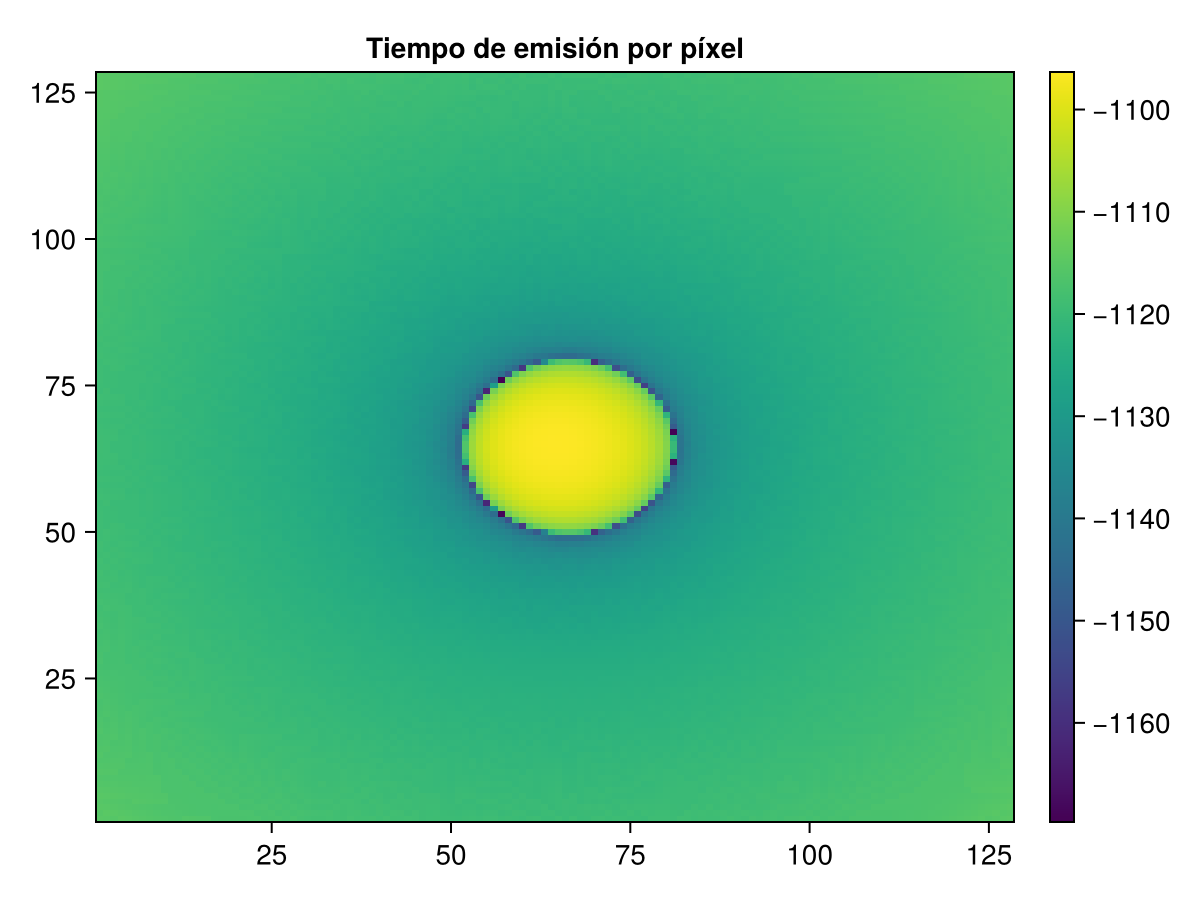

CairoMakie.Screen{IMAGE}


In [2]:
# Tiempo del último paso de cada píxel (el más antiguo = más negativo)
t_emission = [all_geodesics[i,j][end].X[1] for i in 1:128, j in 1:128]

using CairoMakie
fig, ax, hm = heatmap(t_emission)
Colorbar(fig[1,2], hm)
ax.title = "Tiempo de emisión por píxel"
display(fig)

In [2]:
# Tipo general
println("Tipo general")
println(typeof(all_geodesics))
println("========================================")

# Tamaño de la matriz
println("Tamaño de la matriz")
println(size(all_geodesics))
println("========================================")

# Tipo de cada elemento
println("Tipo de cada elemento")
println(typeof(all_geodesics[1,1]))
println("========================================")

# Cuántos pasos tiene esa geodésica
println("Cuántos pasos tiene esa geodésica")
println(length(all_geodesics[1,1]))
println("========================================")

# Ver el primer paso
println(" Ver el primer paso")
println(all_geodesics[1,1][1])
println("========================================")

# Tipo del paso
println("Tipo del paso")
println(typeof(all_geodesics[1,1][1]))
println("========================================")

# Ver los campos del paso
println("Ver los campos del paso")
println(fieldnames(typeof(all_geodesics[1,1][1])))
println("========================================")

Tipo general


LoadError: UndefVarError: `all_geodesics` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [3]:
# Tipo general
println("Tipo general")
println(typeof(nsteps))
println("========================================")

# Tamaño de la matriz
println("Tamaño de la matriz")
println(size(nsteps))
println("========================================")

# Tipo de cada elemento
println("Tipo de cada elemento")
println(typeof(nsteps[1,1]))
println("========================================")


Tipo general


LoadError: UndefVarError: `nsteps` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

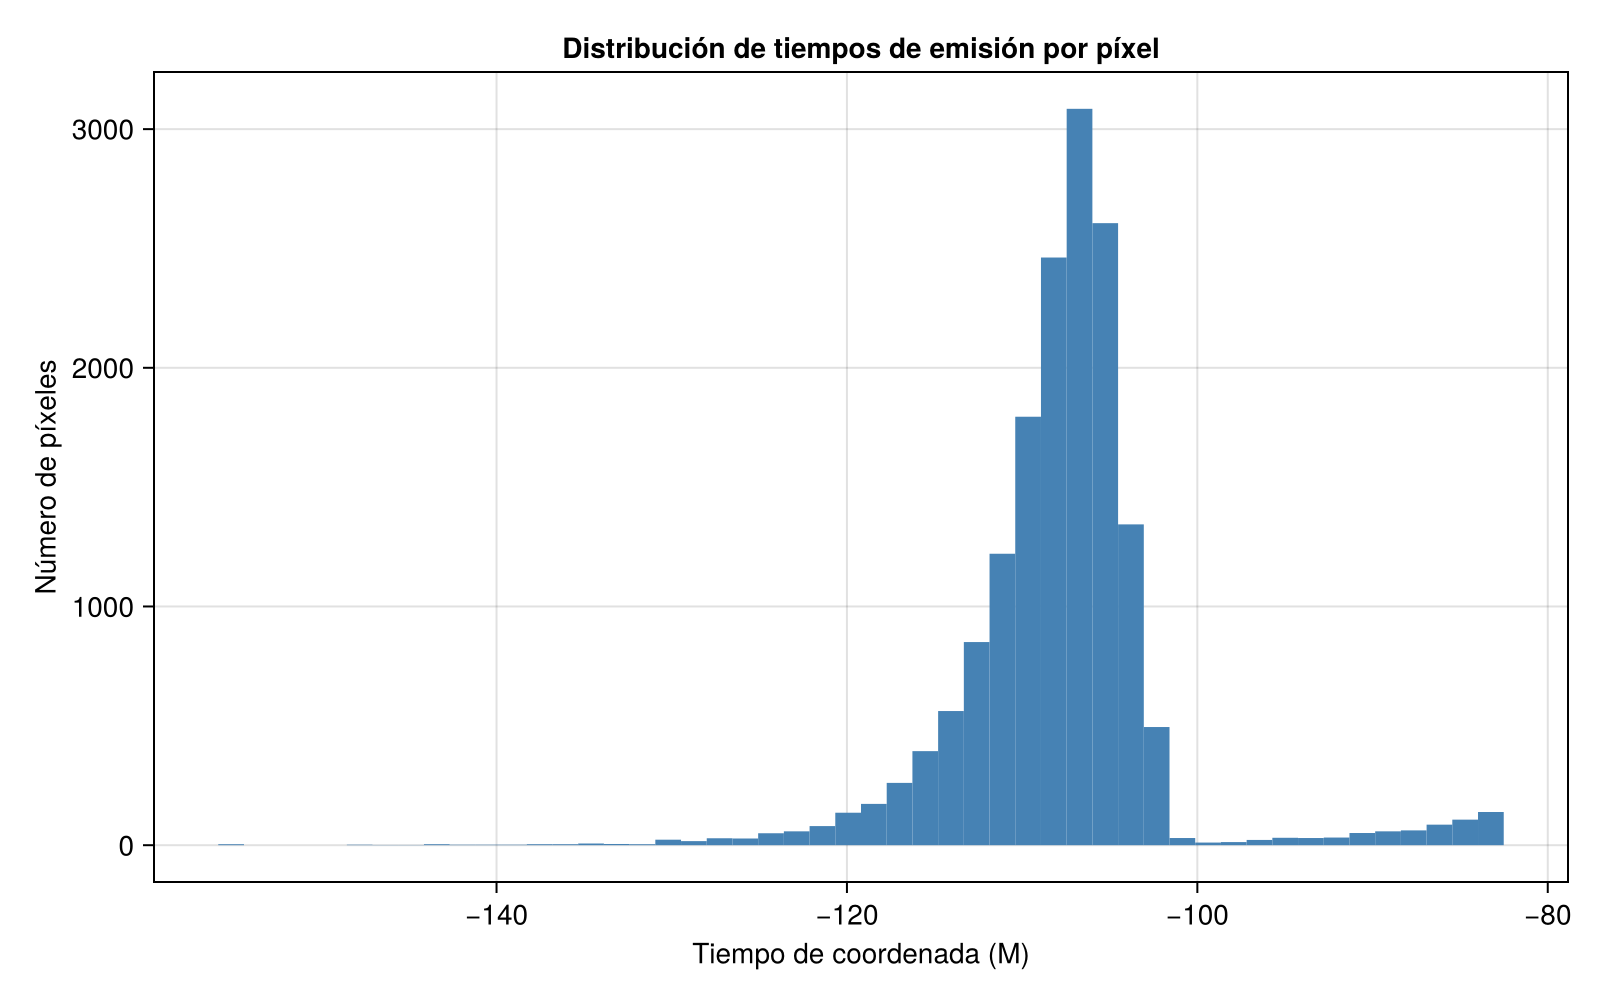

CairoMakie.Screen{IMAGE}


In [16]:
using CairoMakie
using JLD2
using StaticArrays

# Extraer el tiempo del último paso de cada geodésica (tiempo más antiguo = más negativo)
t_emission = [all_geodesics[i,j][end].X[1] for i in 1:128, j in 1:128]

const ro = 1000.0
fact = -(ro + 2*log(ro))
t_emission .-= fact
# Aplanar la matriz a un vector para el histograma
t_flat = vec(t_emission)

# Histograma
fig = Figure(size=(800, 500))
ax = Axis(fig[1,1],
    title = "Distribución de tiempos de emisión por píxel",
    xlabel = "Tiempo de coordenada (M)",
    ylabel = "Número de píxeles"
)
hist!(ax, t_flat, bins=50, color=:steelblue)
display(fig)